# Ridgeline Plot

A ridgeline plot stacks many distributions in rows, one ridge per group, so the eye can follow how a shape shifts across an ordered variable: months, hours, releases, epochs. It answers *where do the values sit, how spread are they, and how does that change from row to row*, for more groups than a grid of histograms could hold. This guide shows how to create ridgeline plots with the [datachart.charts.RidgelinePlot](../../../references/charts/#datachart.charts.RidgelinePlot) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-ridgeline-plot), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import RidgelinePlot

## Basics

The examples in this guide share one dataset: a year of daily mean temperatures in Ljubljana. The monthly means are the station's published 1991–2020 climate normals, rounded; the thirty daily values of each month are illustrative, drawn with a fixed seed around that month's normal, with a wider day-to-day spread in winter than in summer. The data lives in a hidden cell. `temperatures` holds one data point per day, labeled with its month, so the twelve months give twelve ridges. The year has a story in it: a warm, settled summer, and winters where one day can be mild and the next freezing.

In [2]:
import numpy as np

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
# mean monthly temperature in °C (Ljubljana, 1991-2020 normals, rounded)
MONTHLY_MEAN = [0.8, 2.4, 6.8, 11.5, 16.2, 20.1, 22.0, 21.4, 16.6, 11.5, 5.9, 1.3]
# illustrative day-to-day spread in °C, wider in winter
MONTHLY_SPREAD = [4.0, 4.0, 3.5, 3.0, 2.5, 2.5, 2.5, 2.5, 3.0, 3.5, 3.5, 4.0]

rng = np.random.RandomState(11)
temperatures = [
    {"label": month, "value": round(float(celsius), 1)}
    for month, mean, spread in zip(MONTHS, MONTHLY_MEAN, MONTHLY_SPREAD)
    for celsius in rng.normal(mean, spread, 30)
]

Each data point is a dictionary with a `label` (the row) and a numeric `value`; the points that share a label form one ridge:

In [3]:
temperatures[:3]

[{'label': 'Jan', 'value': 7.8},
 {'label': 'Jan', 'value': -0.3},
 {'label': 'Jan', 'value': -1.1}]

**Basic example.** Only the `data` argument is required. Every label draws one ridge, the smoothed density of its values, on its own row. The rows follow the order the labels first appear in the data, the first at the top, and each ridge rises from its row's tick into the row above it, so the year reads top to bottom and the summer bulge shows at a glance:

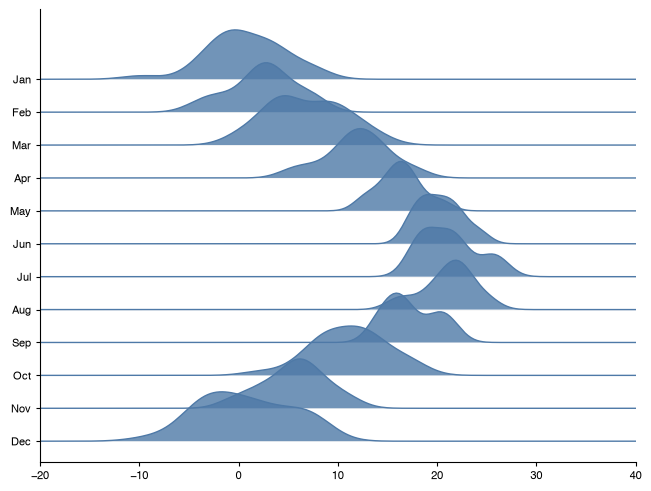

In [4]:
RidgelinePlot(
    # add the data to the chart
    data=temperatures
).show()

## Customizing the Ridgeline Plot

Every customization is either a keyword argument of `RidgelinePlot` or a `plot_ridgeline_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                   | Use                                                         | See |
| :------------------------------------------- | :---------------------------------------------------------- | :-- |
| add a title and axis labels                  | `title`, `xlabel`, `ylabel`                                 | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| place and format the value ticks             | `xticks`, `xticks_format`                                   | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| resize the figure or show the grid           | `figsize`, `show_grid`                                      | [Figure size and grid](#figure-size-and-grid) |
| change the ridge fill, outline, or alpha     | `style={"plot_ridgeline_color": ...}`                       | [Ridge style](#ridge-style) |
| make the rows overlap more or less           | `overlap`                                                   | [Row overlap](#row-overlap) |
| compare the ridge heights, not only shapes   | `normalize`                                                 | [Ridge scale](#ridge-scale) |
| mark the median or the quartiles             | `inner`                                                     | [Inner marks](#inner-marks) |
| draw only the outlines or only the fills     | `fill`, `show_outline`                                      | [Fill and outline](#fill-and-outline) |
| order the rows by their median               | `sort`                                                      | [Row order](#row-order) |
| smooth or sharpen the ridges                 | `bandwidth`                                                 | [Bandwidth](#bandwidth) |
| fix the value range of the ridges            | `xmin`, `xmax`                                              | [Value range](#value-range) |
| stack the rows along the x-axis              | `orientation`                                               | [Orientation](#orientation) |
| highlight some rows, mute the rest           | `emphasis`, `emphasis_rule`                                 | [Emphasis](#emphasis) |
| mark a threshold or shade a range            | `vlines`, `vspans`, `hlines`, `hspans`                      | [Reference lines and bands](#reference-lines-and-bands) |
| title and place the legend                   | `show_legend`, `legend`                                     | [Legend](#legend) |
| put a note on the chart                      | `texts`                                                     | [Text annotations](#text-annotations) |
| draw several ridgelines side by side         | `data` as a list of lists, `subtitle`, `sharex`, `max_cols` | [Multiple Ridgeline Plots](#multiple-ridgeline-plots) |
| overlay the ridges with another chart        | `Panel`                                                     | [Composing with Panel and Grid](#composing-with-panel-and-grid) |
| put the ridgeline next to other charts       | `Grid`                                                      | [Composing with Panel and Grid](#composing-with-panel-and-grid) |
| show values that span orders of magnitude    | `scaley`, `xticks`, `xticklabels`                           | [Axis scales](#axis-scales) |
| plot data with other key names               | `label`, `value`                                            | [Custom data keys](#custom-data-keys) |
| save the chart to a file                     | `save_figure`                                               | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `normalize` | [`RIDGELINE_SCALE`](../../../references/constants/#datachart.constants.RIDGELINE_SCALE) |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |
| `orientation` | [`ORIENTATION`](../../../references/constants/#datachart.constants.ORIENTATION) |
| `scaley` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |
| `xticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `yticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `bandwidth` | [`BANDWIDTH`](../../../references/constants/#datachart.constants.BANDWIDTH) |
| `inner` | [`VIOLIN_INNER`](../../../references/constants/#datachart.constants.VIOLIN_INNER) |
| `sort` | [`SORT`](../../../references/constants/#datachart.constants.SORT) |

The full list of style attributes is in the [datachart.typings.RidgelineStyleAttrs](../../../references/typings/#datachart.typings.RidgelineStyleAttrs) type; the full list of parameters is in the [datachart.charts.RidgelinePlot](../../../references/charts/#datachart.charts.RidgelinePlot) reference.

### Title, axis labels and ticks

Without a title and axis labels the reader cannot tell that the ridges are temperatures, or that the rows are months; `title`, `xlabel` and `ylabel` say it. With the default orientation the value axis is the x-axis and the rows stack along the y-axis. `xticks` places the value ticks where a reader expects them (every 10 °C here), and `xticks_format` formats their labels with any `"{x:.0f}"` style string, so the unit can travel with the numbers.

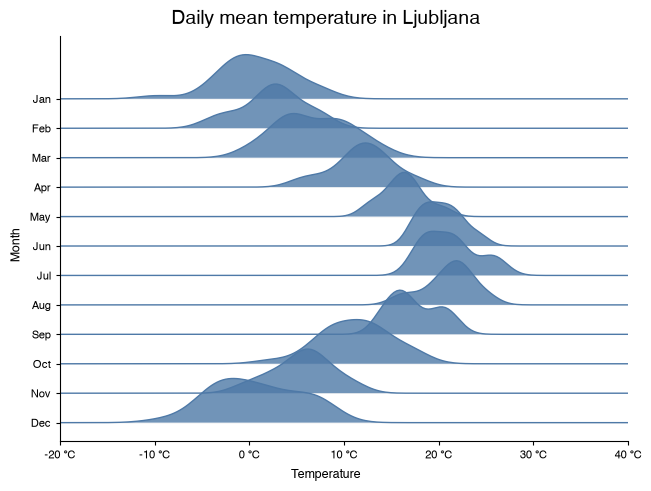

In [5]:
RidgelinePlot(
    data=temperatures,
    # add the title
    title="Daily mean temperature in Ljubljana",
    # add the x and y axis labels
    xlabel="Temperature",
    ylabel="Month",
    # value ticks every 10 °C, with the unit on each
    xticks=[-20, -10, 0, 10, 20, 30, 40],
    xticks_format="{x:.0f} °C",
).show()

### Figure size and grid

Twelve rows need height, and a ridgeline reads best on a figure taller than it is by default. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE), sized for a full or half page width. Vertical grid lines let the eye carry a ridge's peak down to the value axis; `show_grid=SHOW_GRID.X` ([SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID)) draws them along the value axis only, since the rows already have their baselines.

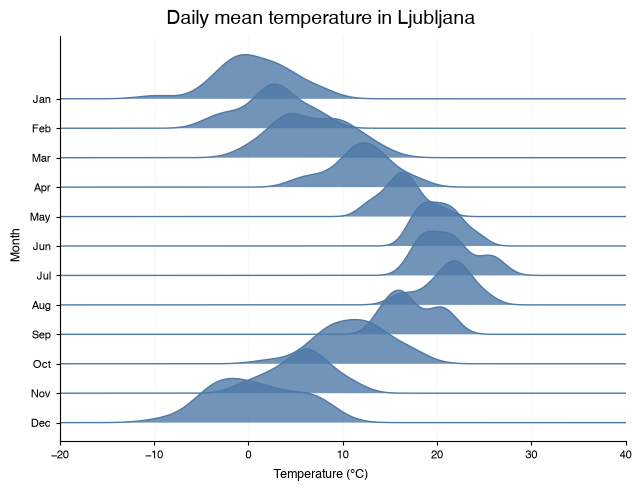

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

RidgelinePlot(
    data=temperatures,
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    ylabel="Month",
    # a full-width, medium-height figure
    figsize=FIG_SIZE.FULL_MEDIUM,
    # grid lines along the value axis only
    show_grid=SHOW_GRID.X,
).show()

### Ridge style

The default look, a translucent fill with an outline of the same color, lets the rows behind show through. The `style` dictionary changes it: the fill color and alpha, the outline color and width, the default overlap, and the color and width of the inner marks; the attributes are listed in [datachart.typings.RidgelineStyleAttrs](../../../references/typings/#datachart.typings.RidgelineStyleAttrs), and any attribute left out keeps the value of the active theme. An opaque fill with a white outline is the classic *joy plot* look: every ridge cuts cleanly into the row behind it, which suits many rows that overlap a lot.

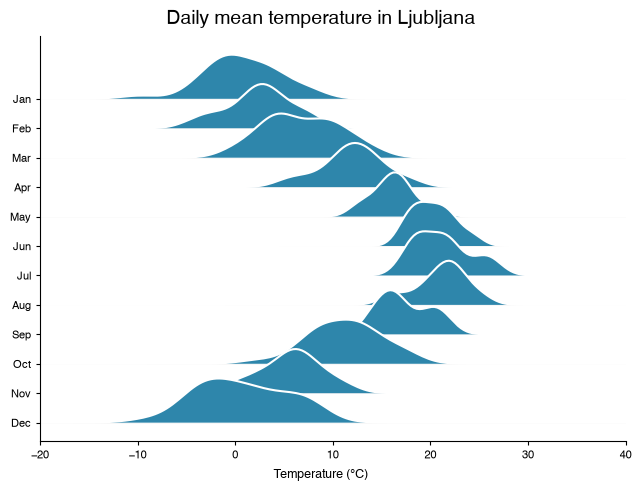

In [7]:
RidgelinePlot(
    data=temperatures,
    # the classic look: an opaque fill cut by a white outline
    style={
        "plot_ridgeline_color": "#2E86AB",
        "plot_ridgeline_alpha": 1.0,
        "plot_ridgeline_edgecolor": "#FFFFFF",
        "plot_ridgeline_linewidth": 1.5,
    },
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Row overlap

Ridges that overlap save space and make the shift from row to row easy to follow; too much overlap hides the rows behind. `overlap` sets how far each ridge rises into the row above, between 0 and 1: a ridge's peak stands `1 + overlap` rows above its tick, so `0` makes the peaks just touch the next row and `1` sends them a whole row further. Without it the theme's `plot_ridgeline_overlap` applies (`0.5` in the predefined themes); values outside `[0, 1]` raise a `ValueError`. Side by side, the flat version is easier to read row by row, and the overlapping one shows the seasonal sweep better.

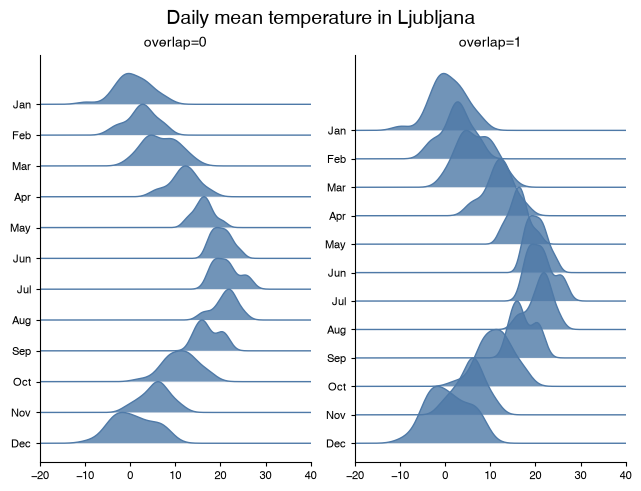

In [8]:
from datachart.utils import Grid

Grid(
    [
        # the peaks just touch the next row
        RidgelinePlot(data=temperatures, overlap=0.0, title="overlap=0"),
        # the peaks rise a whole row further
        RidgelinePlot(data=temperatures, overlap=1.0, title="overlap=1"),
    ],
    title="Daily mean temperature in Ljubljana",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Ridge scale

Summer days in Ljubljana vary less than winter days, so a summer month's values are packed more tightly. The default scale hides that: every ridge is stretched to the same peak height, so the chart compares shapes and positions, the honest choice when the question is *where* each row sits. `normalize` picks the scale from [RIDGELINE_SCALE](../../../references/constants/#datachart.constants.RIDGELINE_SCALE): `RIDGELINE_SCALE.PER_ROW` (the default) or `RIDGELINE_SCALE.COMMON`, where every ridge shares one density scale, the tallest reaches the peak height and the rest stay in proportion. The common scale is the honest choice when the question is *how concentrated* each row is: the narrow summer months stand tall and the variable winter months flatten. Neither scale shows how many values a row holds, since every ridge is a density with the same area; when the row sizes differ a lot, say so in the labels.

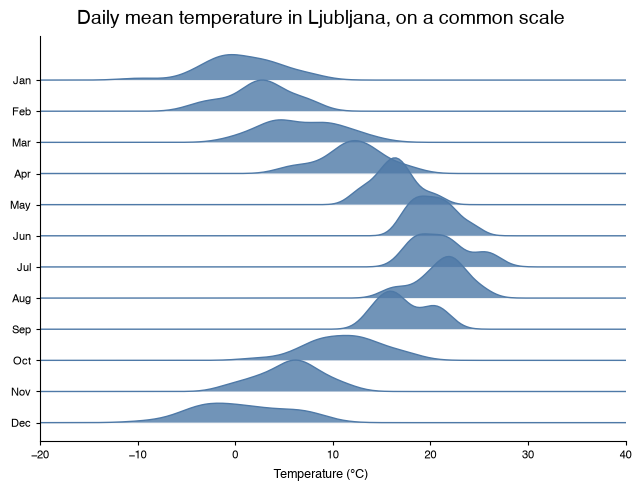

In [9]:
from datachart.constants import RIDGELINE_SCALE

RidgelinePlot(
    data=temperatures,
    # one density scale for every ridge
    normalize=RIDGELINE_SCALE.COMMON,
    title="Daily mean temperature in Ljubljana, on a common scale",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Inner marks

A ridge's peak is not its median, and a skewed row can mislead the eye. `inner` draws summary marks inside each ridge, from its baseline up to the curve: `VIOLIN_INNER.MEDIAN` draws one solid line at the median, `VIOLIN_INNER.QUARTILES` a dashed median and dotted first and third quartiles, and `None` (the default) no marks ([VIOLIN_INNER](../../../references/constants/#datachart.constants.VIOLIN_INNER); `"box"` is not supported and raises a `ValueError`). The quartiles show the middle half of each month's days, wide in winter and narrow in summer. `plot_ridgeline_inner_color` and `plot_ridgeline_inner_linewidth` style the marks.

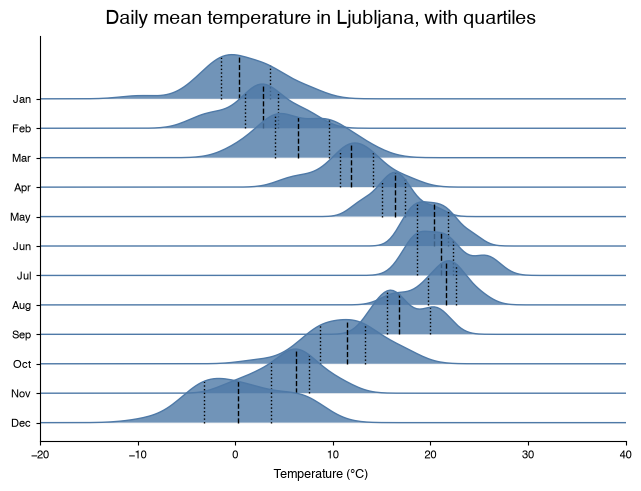

In [10]:
from datachart.constants import VIOLIN_INNER

RidgelinePlot(
    data=temperatures,
    # mark the median and quartiles of every month
    inner=VIOLIN_INNER.QUARTILES,
    title="Daily mean temperature in Ljubljana, with quartiles",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Fill and outline

Filled ridges hide part of the rows behind them, and with a high overlap that can hide the very shift the chart is about. `fill` and `show_outline` turn the fill and the density curve on and off independently; both are on by default. Outlines alone keep every row visible through the overlap, like a stack of contour lines; turning both off raises a `ValueError`, since nothing would be drawn.

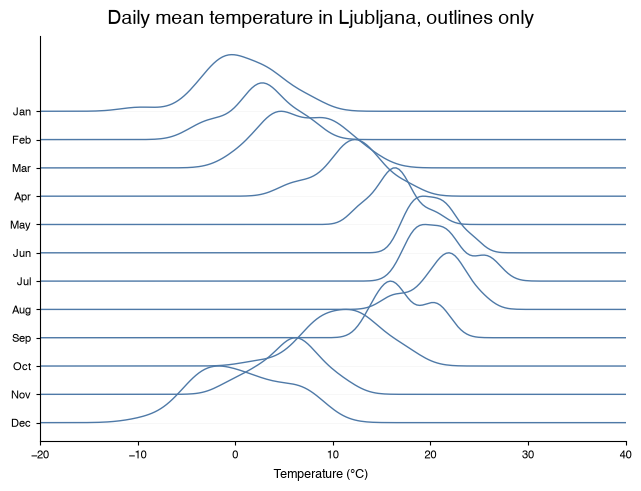

In [11]:
RidgelinePlot(
    data=temperatures,
    # draw only the density curves
    fill=False,
    overlap=1.0,
    title="Daily mean temperature in Ljubljana, outlines only",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Row order

When the rows have a natural order, like months, keep it: the ridgeline is about the shift along that order. When they do not, or when the question is a ranking, `sort` orders the rows by their median ([SORT](../../../references/constants/#datachart.constants.SORT)): `SORT.ASCENDING` puts the smallest median at the top, `SORT.DESCENDING` the largest, and `None` keeps the input order; rows with the same median keep their input order. Sorted from warmest to coldest, the months fall into pairs on either side of midsummer.

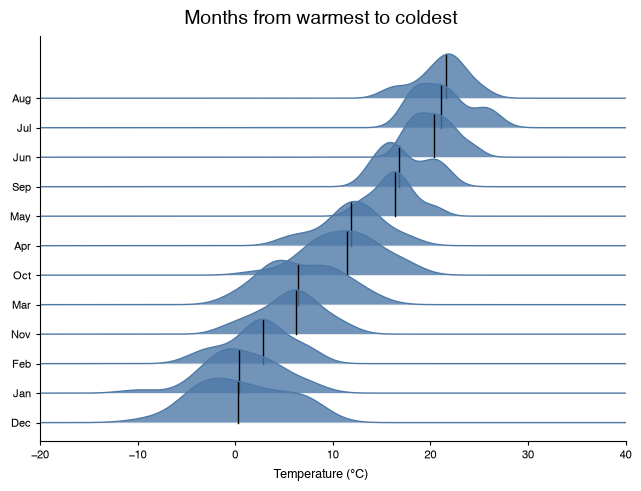

In [12]:
from datachart.constants import SORT

RidgelinePlot(
    data=temperatures,
    # the warmest median at the top
    sort=SORT.DESCENDING,
    inner=VIOLIN_INNER.MEDIAN,
    title="Months from warmest to coldest",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Bandwidth

Each ridge is a kernel density estimate, a smoothed version of the values, and how much it smooths decides what the reader sees: too little and thirty days turn into noise, too much and a real second peak disappears. `bandwidth` takes a rule from [BANDWIDTH](../../../references/constants/#datachart.constants.BANDWIDTH) (`BANDWIDTH.SCOTT`, the default, or `BANDWIDTH.SILVERMAN`) or a scalar factor, where smaller values follow the data more closely and larger ones smooth it more. With only thirty values per row, a narrow bandwidth shows bumps that are sampling noise, not weather; the rules are the safer choice.

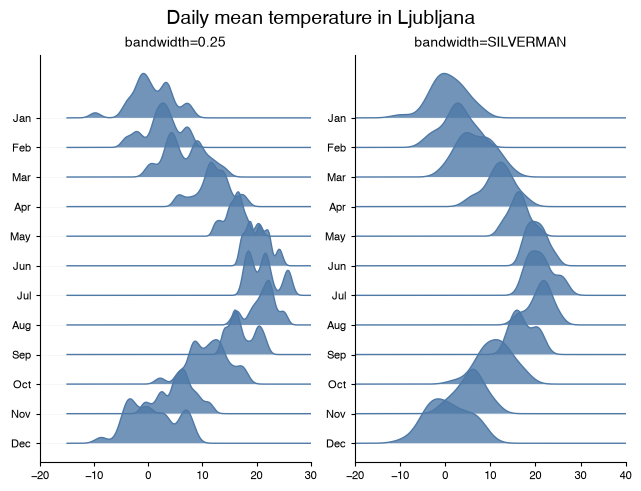

In [13]:
from datachart.constants import BANDWIDTH

Grid(
    [
        # a narrow bandwidth follows every day
        RidgelinePlot(data=temperatures, bandwidth=0.25, title="bandwidth=0.25"),
        # Silverman's rule
        RidgelinePlot(data=temperatures, bandwidth=BANDWIDTH.SILVERMAN, title="bandwidth=SILVERMAN"),
    ],
    title="Daily mean temperature in Ljubljana",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Value range

All ridges are evaluated on one shared grid of values, so the curves line up point for point. By default the grid spans every row's values, extended a little past the extremes so the tails fade out. When a chart must match another one, or a range has a meaning of its own, `xmin` and `xmax` (`ymin` and `ymax` when the rows run vertically) fix both the axis and the grid, so the ridges stop exactly at the axis limits. Every day of the year lies between -10 and 30 °C, a round frame for a temperate climate; the smoothing spreads the winter ridges a little past the coldest day, and the limit cuts those tails.

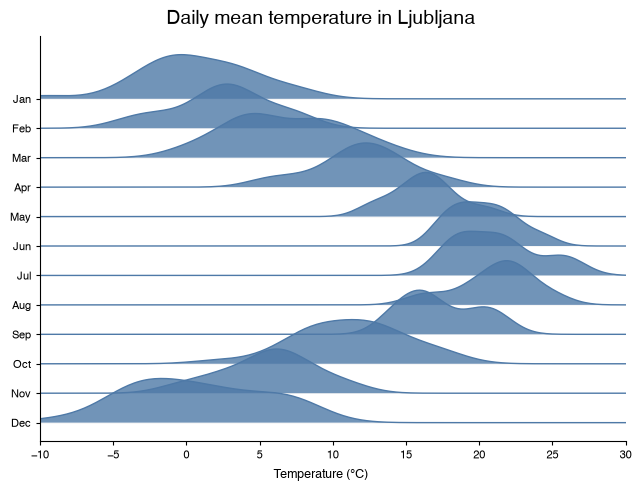

In [14]:
RidgelinePlot(
    data=temperatures,
    # the ridges and the axis both span -10 to 30 °C
    xmin=-10,
    xmax=30,
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Orientation

Temperature is a height on a thermometer, and some readers expect it on a vertical axis. `orientation=ORIENTATION.VERTICAL` ([ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION)) puts the values on the y-axis and runs the rows along the x-axis, the first on the left, each ridge rising to the right from its tick; the axis labels swap with it. `ORIENTATION.HORIZONTAL` is the default. The vertical layout suits a wide figure with short row labels; with long labels, stay horizontal.

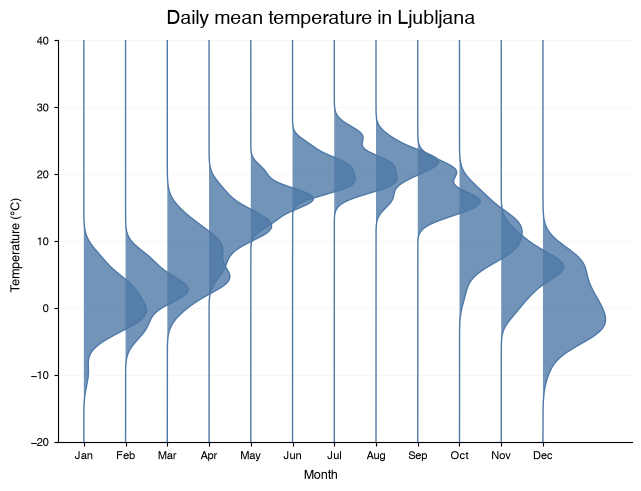

In [15]:
from datachart.constants import ORIENTATION

RidgelinePlot(
    data=temperatures,
    # the rows run left to right
    orientation=ORIENTATION.VERTICAL,
    title="Daily mean temperature in Ljubljana",
    # the axis labels swap with the orientation
    xlabel="Month",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Emphasis

A chart usually makes one point, and emphasis makes it visible. `emphasis` takes one role per row, aligned with the row labels in the order they first appear in the data (here January to December), whatever the `sort`: `"highlight"` bolds a ridge's outline, `"background"` mutes the ridge and its inner marks into the theme's muted color, and `None` leaves it as it is; a single value applies to every row. The roles are also available as the [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants, and the [Highlighting](../../styling/highlighting/) guide covers emphasis across chart types and themes. Muting every month but July points at the warmest month:

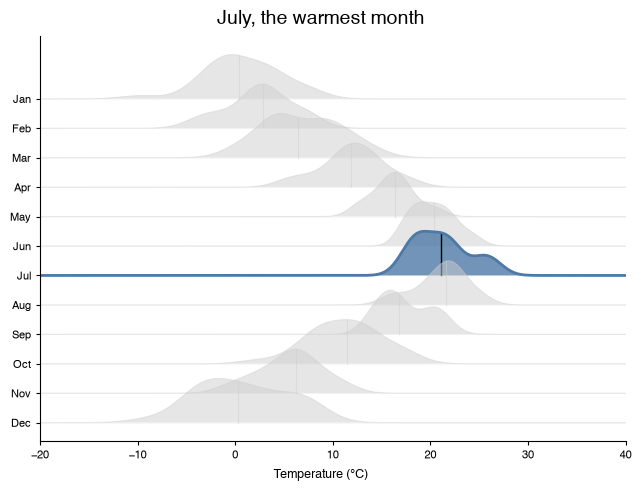

In [16]:
from datachart.constants import EMPHASIS

RidgelinePlot(
    data=temperatures,
    # one role per month, January first
    emphasis=[EMPHASIS.BACKGROUND] * 6 + [EMPHASIS.HIGHLIGHT] + [EMPHASIS.BACKGROUND] * 5,
    inner=VIOLIN_INNER.MEDIAN,
    title="July, the warmest month",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

`emphasis_rule` picks the rows from the data instead of listing them by hand. It is a one-key rule: `{"above": v}` or `{"below": v}` (strict), `{"between": (lo, hi)}` (inclusive), `{"top": n}` or `{"bottom": n}`, read against a summary of each row, the median by default; a `"by"` key picks `"mean"`, `"min"`, `"max"` or `"sum"` instead. The rows that match are highlighted and the rest muted, and an explicit `emphasis` role wins over the rule. Reading the rule against each month's coldest day (`"by": "min"`) picks out every month with at least one freezing day:

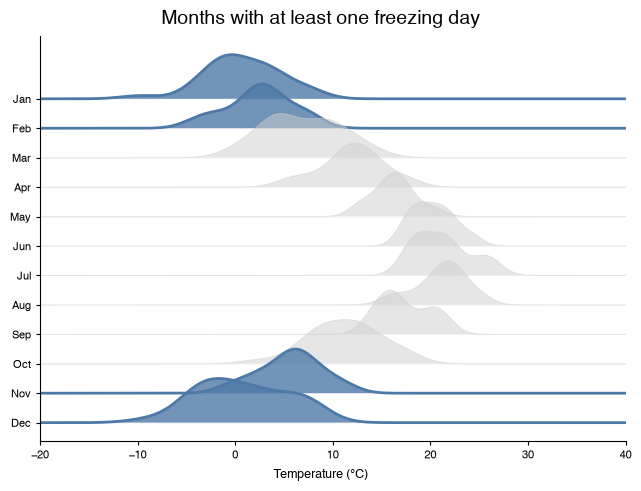

In [17]:
RidgelinePlot(
    data=temperatures,
    # highlight the months whose coldest day was below freezing
    emphasis_rule={"below": 0, "by": "min"},
    title="Months with at least one freezing day",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Reference lines and bands

A threshold turns a distribution into an answer: how much of each month lies below freezing, or inside a comfortable range. With the default orientation the value axis is the x-axis, so `vlines` draws a vertical line at a value and `vspans` shades a range of values; `hlines` and `hspans` work along the row axis, where the rows sit at positions `1`, `2`, `3`, … from the top. Each takes a dictionary or a list of them, with the position, an optional `label` for the legend and a `style`; the keys are listed in [VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs), [VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs), [HLineSettingAttrs](../../../references/typings/#datachart.typings.HLineSettingAttrs) and [HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs). The example marks the freezing point with a dashed line and shades 18 to 24 °C, a comfortable range for a day outdoors.

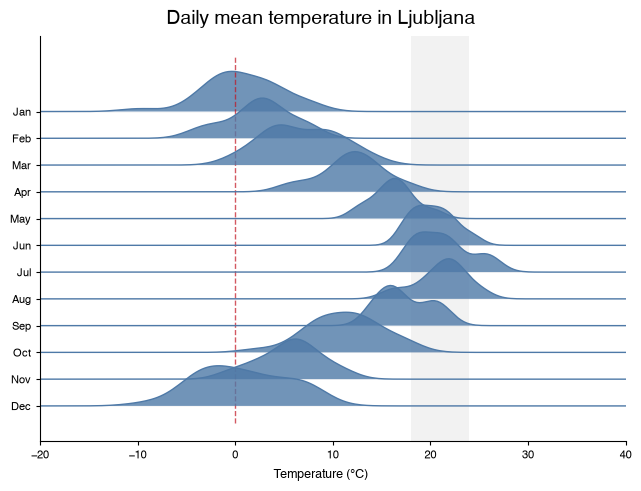

In [18]:
from datachart.constants import LINE_STYLE

RidgelinePlot(
    data=temperatures,
    # a dashed line at the freezing point
    vlines={
        "x": 0,
        "label": "freezing",
        "style": {"plot_vline_color": "#c1121f", "plot_vline_style": LINE_STYLE.DASHED},
    },
    # shade the comfortable range
    vspans={"xmin": 18, "xmax": 24, "label": "comfortable"},
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Legend

The ridges add no legend entries, since their labels already sit on the row axis; the legend is for the reference lines and bands. `show_legend` lists them, and `legend` says where and how, with a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), the number of columns `ncols` and the `alignment` of the entries from [LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN); a field left out falls back to the theme ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). The ridges fill the plot area, so the legend goes outside it, to the right.

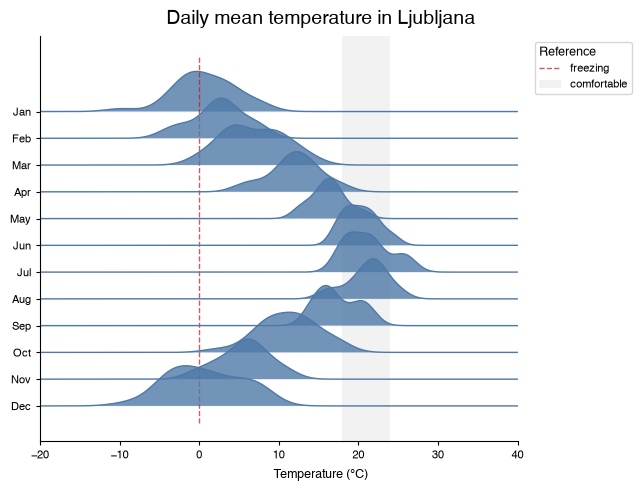

In [19]:
from datachart.constants import LEGEND_LOCATION

RidgelinePlot(
    data=temperatures,
    vlines={
        "x": 0,
        "label": "freezing",
        "style": {"plot_vline_color": "#c1121f", "plot_vline_style": LINE_STYLE.DASHED},
    },
    vspans={"xmin": 18, "xmax": 24, "label": "comfortable"},
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    # list the reference line and band
    show_legend=True,
    # a titled legend outside the axes
    legend={"title": "Reference", "location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

### Text annotations

Where a reference line marks a value, a note explains a row. `texts` places text on the chart, with an optional `target` to draw a connector to a point; the position is in data coordinates by default (value, row position) or in axes fractions with `"coords": "axes"`, which keeps the note in place whatever the axis limits. Rows sit at positions `1`, `2`, `3`, … from the top, and a ridge rises toward smaller positions: `(4, 0.6)` is a point inside January's ridge, just above its baseline. The [Text Annotations](../../utility/annotations/) guide covers placement, connector looks and styling.

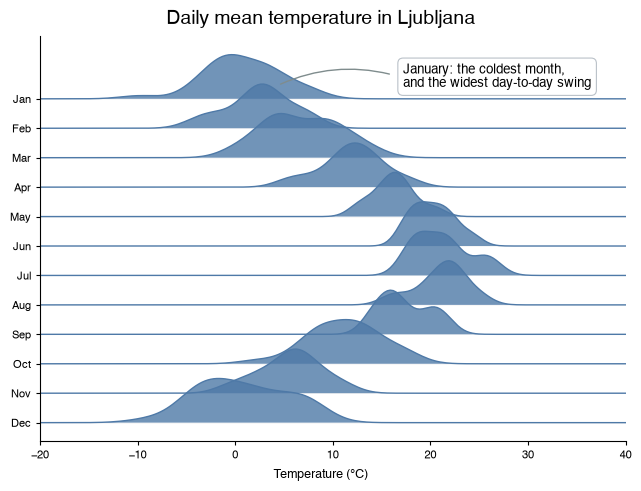

In [20]:
RidgelinePlot(
    data=temperatures,
    # a note pinned to the axes, pointing into January's ridge
    texts={
        "text": "January: the coldest month,\nand the widest day-to-day swing",
        "x": 0.62,
        "y": 0.9,
        "coords": "axes",
        "target": (4, 0.6),
    },
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Multiple Ridgeline Plots

To compare two sets of rows, pass a list of lists to `data`: each inner list is one ridgeline, drawn in its own subplot, and the per-chart attributes (`subtitle`, `style`, `emphasis`, `vlines`, …) become lists aligned with it. `subtitle` titles the subplots, while `title`, `xlabel` and `ylabel` stay global; `max_cols` limits the subplots per row. `sharex=True` puts every subplot on one value axis, so a ridge in one subplot compares with a ridge in the next (`sharey` shares the row axis, which only makes sense when the subplots have the same rows); the ridges of every subplot are evaluated over one shared value range either way. Here the year is split into its cold half (October to March) and its warm half (April to September), each in its own color.

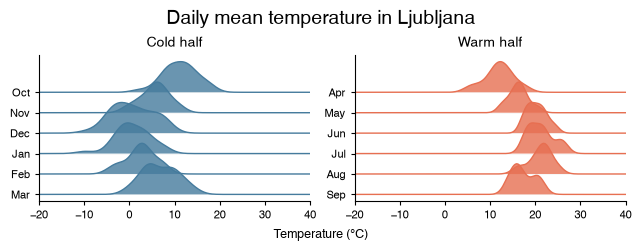

In [21]:
COLD = ["Oct", "Nov", "Dec", "Jan", "Feb", "Mar"]

WARM = ["Apr", "May", "Jun", "Jul", "Aug", "Sep"]

# each half in its own month order, the rows follow it
halves = [
    [point for month in half for point in temperatures if point["label"] == month]
    for half in (COLD, WARM)
]

RidgelinePlot(
    # one ridgeline per half of the year
    data=halves,
    # a title and a color per subplot
    subtitle=["Cold half", "Warm half"],
    style=[{"plot_ridgeline_color": "#457b9d"}, {"plot_ridgeline_color": "#e76f51"}],
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    # side by side, on one temperature axis
    max_cols=2,
    sharex=True,
).show()

### Composing with Panel and Grid

A ridgeline says where a row's values sit; it does not show the values themselves. [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) overlays figures in one coordinate space, with one ridgeline per panel, and a [SwarmPlot](../../../references/charts/#datachart.charts.SwarmPlot) of the same data puts every day under its month's ridge: over ridges, the panel packs the swarm on the side the ridges rise to, so each day sits inside its month's ridge. The swarm must share the horizontal orientation, and a small, dark point keeps the days readable over the fill. The panel keeps the first row at the top for every chart in it, and labels its axes by role: `xlabel` names the category axis and `ylabel_left` the value axis, wherever they are drawn. The [Panel](../../utility/panel/) guide covers the rest.

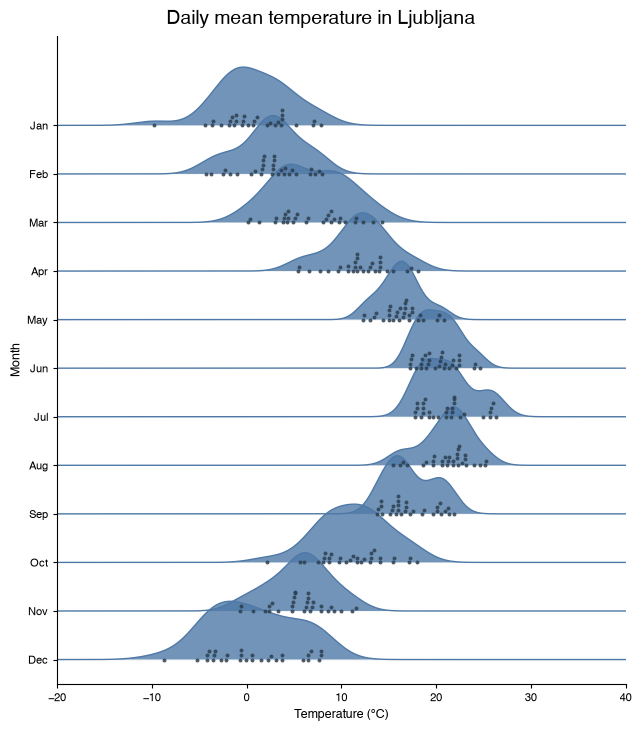

In [22]:
from datachart.charts import SwarmPlot
from datachart.utils import Panel

Panel(
    [
        RidgelinePlot(data=temperatures, overlap=0.2),
        # one point per day, on its month's row
        SwarmPlot(
            data=temperatures,
            orientation=ORIENTATION.HORIZONTAL,
            style={"plot_swarm_color": "#2C3E50", "plot_swarm_size": 8},
        ),
    ],
    title="Daily mean temperature in Ljubljana",
    # Panel labels the axes by role: the category axis, then the value axis
    xlabel="Month",
    ylabel_left="Temperature (°C)",
    figsize=FIG_SIZE.FULL_TALL,
).show()

[datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) puts a ridgeline next to other figures, each in a cell of its own; here a horizontal [BoxPlot](../../../references/charts/#datachart.charts.BoxPlot) of the same months sits beside it, so the reader sees the shape and the summary together. With `sharex` and `sharey` the two charts share both axes: the months line up row for row, and the box plot follows the ridgeline's first-row-at-the-top order. The [Grid](../../utility/grid/) guide covers layouts.

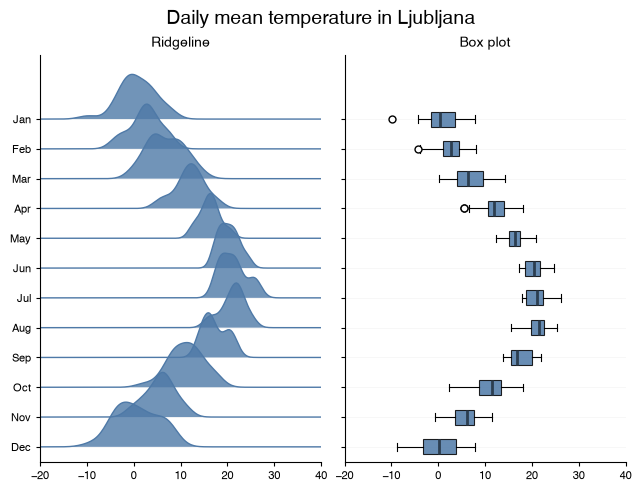

In [23]:
from datachart.charts import BoxPlot

Grid(
    [
        RidgelinePlot(data=temperatures, title="Ridgeline"),
        BoxPlot(data=temperatures, orientation=ORIENTATION.HORIZONTAL, title="Box plot"),
    ],
    title="Daily mean temperature in Ljubljana",
    # one temperature axis and one month axis for both charts
    sharex=True,
    sharey=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Additional Features

### Axis scales

Some values span orders of magnitude, and on a linear axis the small ones collapse into a spike at zero. `scaley` sets the scale of the value axis, whichever direction it runs, with a [SCALE](../../../references/constants/#datachart.constants.SCALE) member. The ridges, though, are estimated at evenly spaced values, so on a log axis the rows with small values get only a few of them and turn jagged. For data that spans orders of magnitude, estimate the ridges on the logarithm of the values instead, and label the ticks in the original unit with `xticks` and `xticklabels`. `response_times`, defined in a hidden cell, holds illustrative response times of three API endpoints, from a health check of a few milliseconds to a report that takes over a second; on the log scale all three ridges are readable, and the right-skewed response times turn into symmetric bumps.

In [24]:
rng = np.random.RandomState(3)
# illustrative response times in ms: (endpoint, median)
ENDPOINTS = [("/health", 4), ("/search", 80), ("/report", 1500)]
response_times = [
    {"label": endpoint, "value": round(float(ms), 2)}
    for endpoint, median in ENDPOINTS
    for ms in rng.lognormal(np.log(median), 0.4, 300)
]

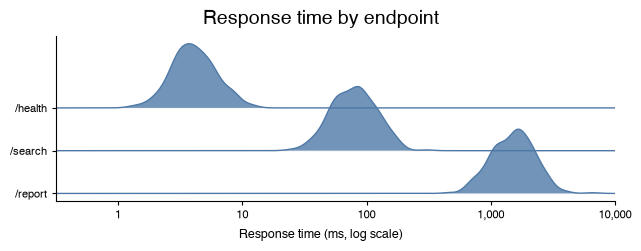

In [25]:
# the ridges are estimated on the log of each value
log_response_times = [
    {"label": point["label"], "value": np.log10(point["value"])} for point in response_times
]

RidgelinePlot(
    data=log_response_times,
    # ticks at the powers of ten, labeled in milliseconds
    xticks=[0, 1, 2, 3, 4],
    xticklabels=["1", "10", "100", "1,000", "10,000"],
    title="Response time by endpoint",
    xlabel="Response time (ms, log scale)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Custom data keys

Data that comes from a file or an API rarely uses the `label` and `value` keys, and renaming every record just to plot it is a chore. Instead, tell `RidgelinePlot` which keys to read with the `label` and `value` arguments. `records` stores the days the way a weather export would, with a `month` and a `celsius` key:

In [26]:
records = [{"month": point["label"], "celsius": point["value"]} for point in temperatures]
records[:2]

[{'month': 'Jan', 'celsius': 7.8}, {'month': 'Jan', 'celsius': -0.3}]

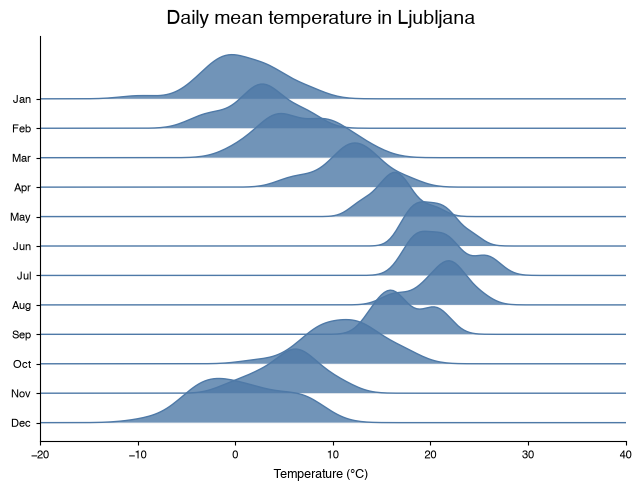

In [27]:
RidgelinePlot(
    data=records,
    # the keys that hold the row and the value
    label="month",
    value="celsius",
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Real-World Examples

The examples below put the features above to work, each one answering a question. Their data is illustrative: drawn with a fixed seed around realistic values, so every run draws the same chart. The data lives in hidden cells; each example says what its data is.

### Example 1: Which Releases Slowed the Service Down? (Median Marks, an Emphasis Rule, and a Target Line)

A service team tracks the response times of eight releases against a 300 ms target. `latency` holds 400 illustrative response times per release, skewed to the right like real latencies: release 2.3 regressed, 2.4 fixed it, and 2.6 slipped again. The rows stay in release order, so a shift reads as a change over time. The median marks show where each release typically lands, `emphasis_rule={"above": 200}` highlights the releases whose median crossed 200 ms, and the dashed line shows the target, named in a legend outside the axes. `xmin` and `xmax` cut the long tail at 600 ms so the bulk of each ridge stays readable.

In [28]:
rng = np.random.RandomState(7)
# illustrative median response time (ms) of each release
RELEASES = {"2.0": 150, "2.1": 145, "2.2": 170, "2.3": 240, "2.4": 160, "2.5": 150, "2.6": 210, "2.7": 135}
latency = [
    {"label": f"v{release}", "value": round(float(ms), 1)}
    for release, median in RELEASES.items()
    for ms in rng.lognormal(np.log(median), 0.3, 400)
]

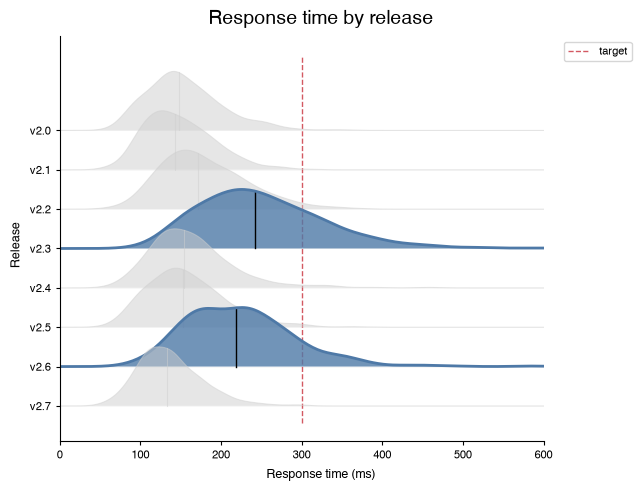

In [29]:
RidgelinePlot(
    data=latency,
    inner=VIOLIN_INNER.MEDIAN,
    # highlight the releases whose median crossed 200 ms
    emphasis_rule={"above": 200},
    vlines={
        "x": 300,
        "label": "target",
        "style": {"plot_vline_color": "#c1121f", "plot_vline_style": LINE_STYLE.DASHED},
    },
    show_legend=True,
    legend={"title": "", "location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    xmin=0,
    xmax=600,
    title="Response time by release",
    xlabel="Response time (ms)",
    ylabel="Release",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 2: Does Training Make the Model More Confident? (Common Density Scale, Outlines, and Quartiles)

A research figure tracks how confident a classifier is on its validation set after each epoch. `confidence` holds 500 illustrative predicted probabilities of the true class per epoch, drawn from beta distributions that move toward 1 as training goes on. With `normalize=RIDGELINE_SCALE.COMMON` the ridges share one density scale, so the distribution visibly narrows and grows taller as training sharpens it; a per-row scale would draw every epoch at the same height and hide exactly that. Outlines alone keep the later epochs visible through the overlap, the quartile marks show the middle half of each epoch moving right, and `xmin` and `xmax` bound the ridges to the valid range of a probability.

In [30]:
rng = np.random.RandomState(5)
# illustrative beta parameters per epoch, sharpening toward 1
EPOCH_BETA = [(2, 2), (3, 2), (5, 2.2), (8, 2.2), (14, 2.5), (22, 2.6)]
confidence = [
    {"label": f"Epoch {epoch}", "value": round(float(p), 3)}
    for epoch, (a, b) in enumerate(EPOCH_BETA, start=1)
    for p in rng.beta(a, b, 500)
]

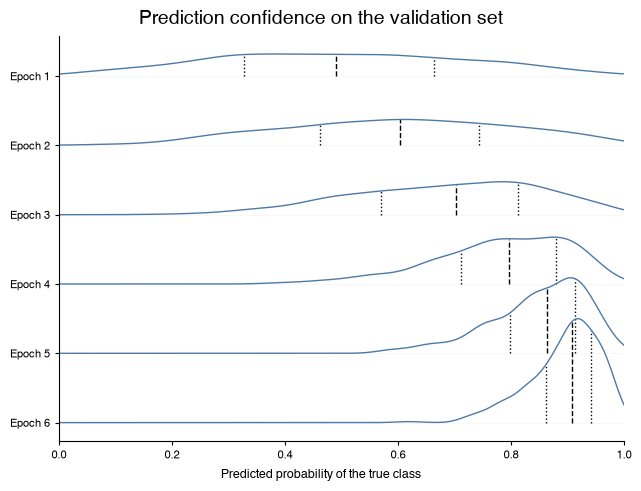

In [31]:
RidgelinePlot(
    data=confidence,
    # one density scale, so the heights compare
    normalize=RIDGELINE_SCALE.COMMON,
    fill=False,
    inner=VIOLIN_INNER.QUARTILES,
    # a probability lives between 0 and 1
    xmin=0,
    xmax=1,
    title="Prediction confidence on the validation set",
    xlabel="Predicted probability of the true class",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 3: How Do Schools Compare, Student by Student? (Sorted Rows, a Pass Mark, and a Strip in a Panel)

An education report ranks eight schools by their median exam score and shows every student. `scores` holds 60 illustrative scores (0 to 100) per school. The ridgeline sorts the schools by median, the best at the top, and `emphasis_rule={"bottom": 1}` highlights the school with the lowest median, the one the report is about; a dashed line marks a pass mark of 50. [Panel](../../utility/panel/) lays a [SwarmPlot](../swarmplot/) in strip mode over the same rows, so the reader sees how many students each ridge stands for and how many fall below the line; small, translucent points keep 480 students readable.

In [32]:
rng = np.random.RandomState(12)
# illustrative mean exam score of each school
SCHOOLS = {"Northgate": 71, "Riverside": 64, "Hillcrest": 78, "Lakeview": 58, "Oakwood": 69, "Westfield": 74, "Brookside": 61, "Elmhurst": 66}
scores = [
    {"label": school, "value": round(float(np.clip(score, 0, 100)))}
    for school, mean in SCHOOLS.items()
    for score in rng.normal(mean, 11, 60)
]

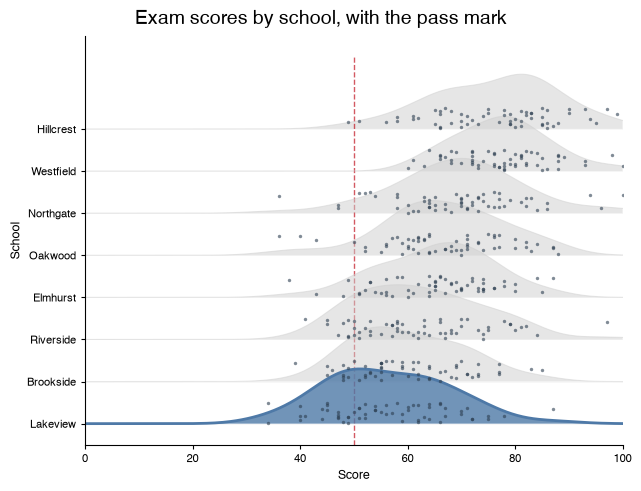

In [33]:
from datachart.constants import SWARM_MODE

Panel(
    [
        RidgelinePlot(
            data=scores,
            # the best median at the top
            sort=SORT.DESCENDING,
            overlap=0.3,
            # a score lives between 0 and 100
            xmin=0,
            xmax=100,
            # the school with the lowest median
            emphasis_rule={"bottom": 1},
            # the pass mark
            vlines={
                "x": 50,
                "style": {"plot_vline_color": "#c1121f", "plot_vline_style": LINE_STYLE.DASHED},
            },
        ),
        # every student, on their school's row
        SwarmPlot(
            data=scores,
            orientation=ORIENTATION.HORIZONTAL,
            mode=SWARM_MODE.STRIP,
            jitter=0.5,
            style={"plot_swarm_color": "#2C3E50", "plot_swarm_size": 6, "plot_swarm_alpha": 0.6},
        ),
    ],
    title="Exam scores by school, with the pass mark",
    xlabel="School",
    ylabel_left="Score",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()